# Input files for KUL-TN-21

### Setup notebook

In [2]:
# Alow changes to the PlatoSim code outside this notebook
%load_ext autoreload
%autoreload 2

# Configure figure in notebook
%matplotlib notebook

### Imports

In [3]:
# Second part libraries
import os
import sys
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import median_filter

# PlatoSim libraries
from platosim.simfile import SimFile
from platosim.plot import plotPhotometry
from platosim.utilities import errorcode, normalize
from platosim.lightcurve import LightCurve
from platosim.matplotlibrc import setup_notebook
setup_notebook()

---
## Correct pandas columns
---

In [7]:
# # User parameters
# idir = "/STER/platodata/PLATOSIM/simulations_PLATO-PL-KUL-TN-0020/P1"
# odir = "/STER/platodata/PLATOSIM/simulations_PLATO-PL-KUL-TN-0020/P1_corrected"
# # Correct columns
# phot = LightCurve(idir, mode="multi")
# phot.correct_and_save(idir, odir, numBegin=818, numEnd=1000)

In [90]:
# idir = "/STER/platodata/PLATOSIM/simulations_PLATO-PL-KUL-TN-0020/P1"
# ofile = os.getcwd() + "/bad_pandas.txt"
# phot = LightCurve(idir, mode="multi")
# phot.bad_files(ofile, numBegin=3, numEnd=4)

---
## Download and plot light curve
---

In [4]:
idir = "/STER/platodata/PLATOSIM/simulations_PLATO-PL-KUL-TN-0020/P1_corrected/000000004"
phot = LightCurve(idir, mode="multi")

# To fetch a specific light curve use instead:
# lc = LightCurve(f"{idir}/000000083/000000083_Ncam1.1_Q23.ftr")

In [5]:
# Unzip all compressed files for the same star
phot.unpack()

In [6]:
# Fetch the first file
filenames = phot.files("ftr")
filenames[0]

'/STER/platodata/PLATOSIM/simulations_PLATO-PL-KUL-TN-0020/P1_corrected/000000004/000000004_Ncam1.1_Q23.ftr'

In [37]:
# Fetch light curve
lc = LightCurve(filenames[0])
lc.data().head()

,flux,cx,cy,bg,flux_err,cx_err,time,cy_err,bg_err,chi2,iter,lamb
0,571078.704086,3.412664,2.577024,1346.755107,858.220918,0.000617,171072012.5,0.000764,13.691124,34.107857,7.0,1.234568
1,573237.059966,3.416376,2.576566,1335.370567,859.480121,0.000616,171072037.5,0.000763,13.679423,35.236626,8.0,0.000015
2,572022.144305,3.415353,2.579708,1319.163363,858.631582,0.000617,171072062.5,0.000763,13.657157,33.933103,6.0,100000.000000
3,572029.692155,3.416559,2.581125,1334.570705,858.594044,0.000617,171072087.5,0.000764,13.673258,33.890364,6.0,100000.000000
4,572986.923317,3.414959,2.581855,1371.651002,859.538288,0.000616,171072112.5,0.000762,13.726386,35.045909,7.0,33333.333333


In [29]:
# Get target star information
star = lc.star_info(phot.files("cat")[0])
print(f"""
Pmag : {star[0]}
rOA  : {star[1]}
rCOB : {star[2]}
nCon : {star[3]}
rCon : {star[4]}
dMag : {star[5]}
SPR  : {star[6]}
""")


Pmag : 9.55
rOA  : 12.082928969863877
rCOB : 0.3102142455478948
nCon : 8
rCon : 1.1128322834154434
dMag : 0.8300000000000018
SPR  : 1.679220001716445



In [30]:
# Get noise-less light curve
lc.varsource()

,time,gran,puls,sum
0,171072000.0,22.792661,-0.707734,22.084927
1,171072025.0,26.577298,-7.865304,18.711994
2,171072050.0,20.054023,-12.840985,7.213037
3,171072075.0,16.220701,-14.127791,2.092909
4,171072100.0,6.331240,-11.486065,-5.154825
...,...,...,...,...
622075,186623875.0,21.525189,-7.551232,13.973957
622076,186623900.0,26.051495,-5.238417,20.813078
622077,186623925.0,33.261030,-1.378547,31.882483
622078,186623950.0,30.923211,3.029651,33.952862


<IPython.core.display.Javascript object>


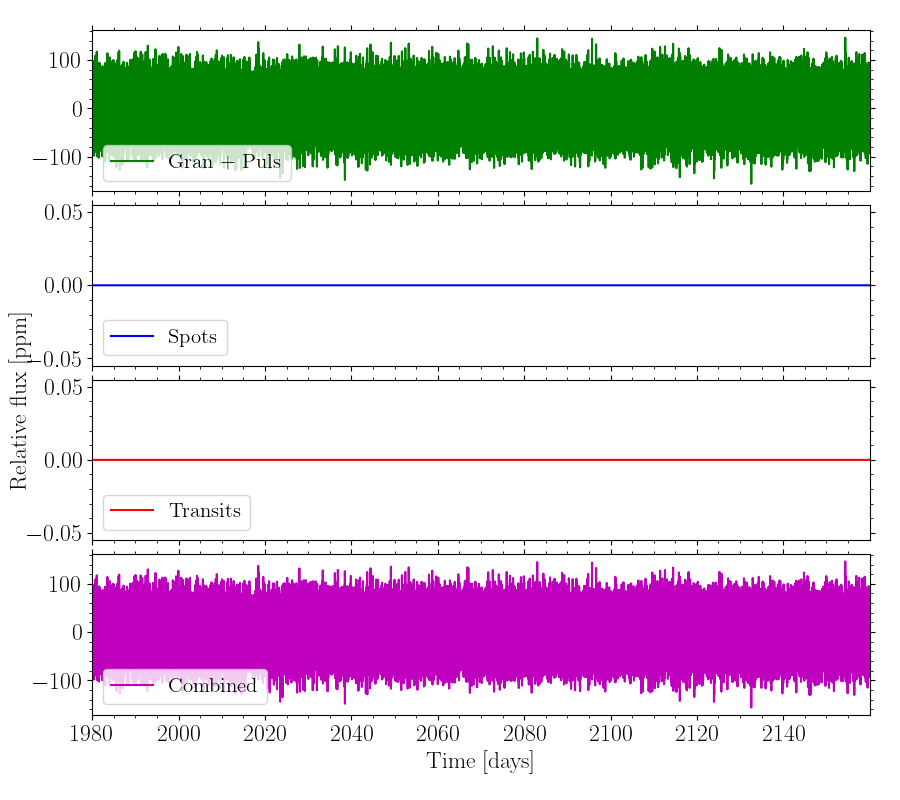

In [31]:
# Plot the input noise-less light curve
fig, ax = lc.plot_varsource();

<IPython.core.display.Javascript object>


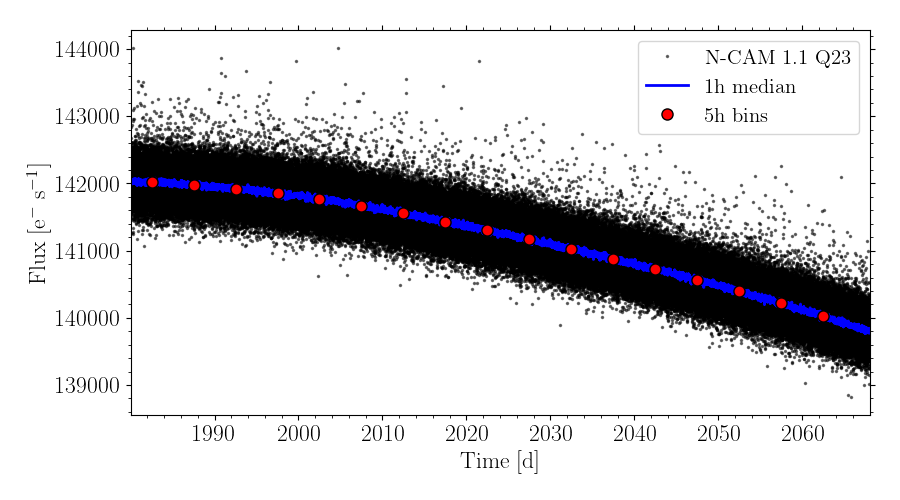

In [38]:
# Plot the simulation, running median, and binned data
fig, ax = lc.plot(time_unit="d", binsize=5, median_filter=1);

<IPython.core.display.Javascript object>


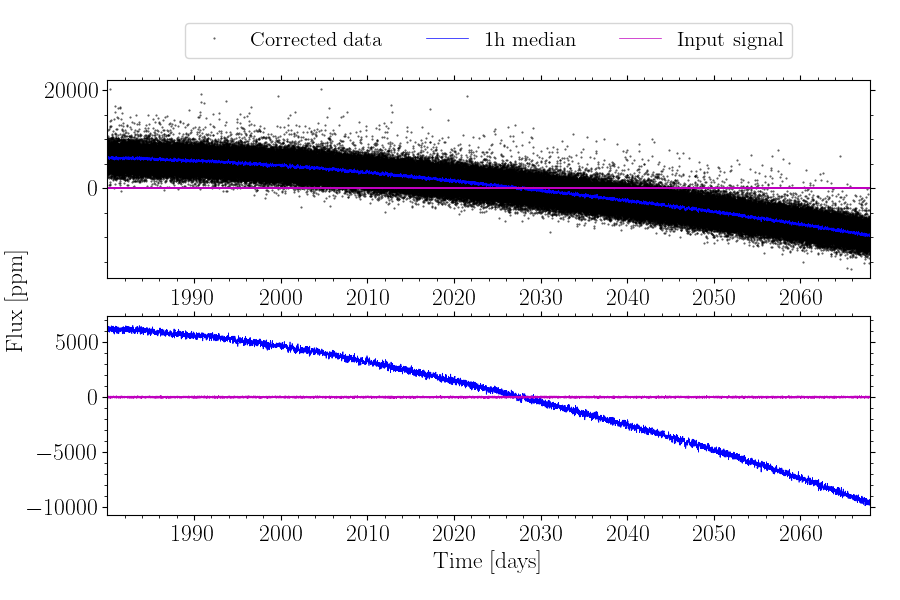

In [12]:
# Plot a quick O-C comparison plot 
fig, ax = lc.plot_oc();

<IPython.core.display.Javascript object>


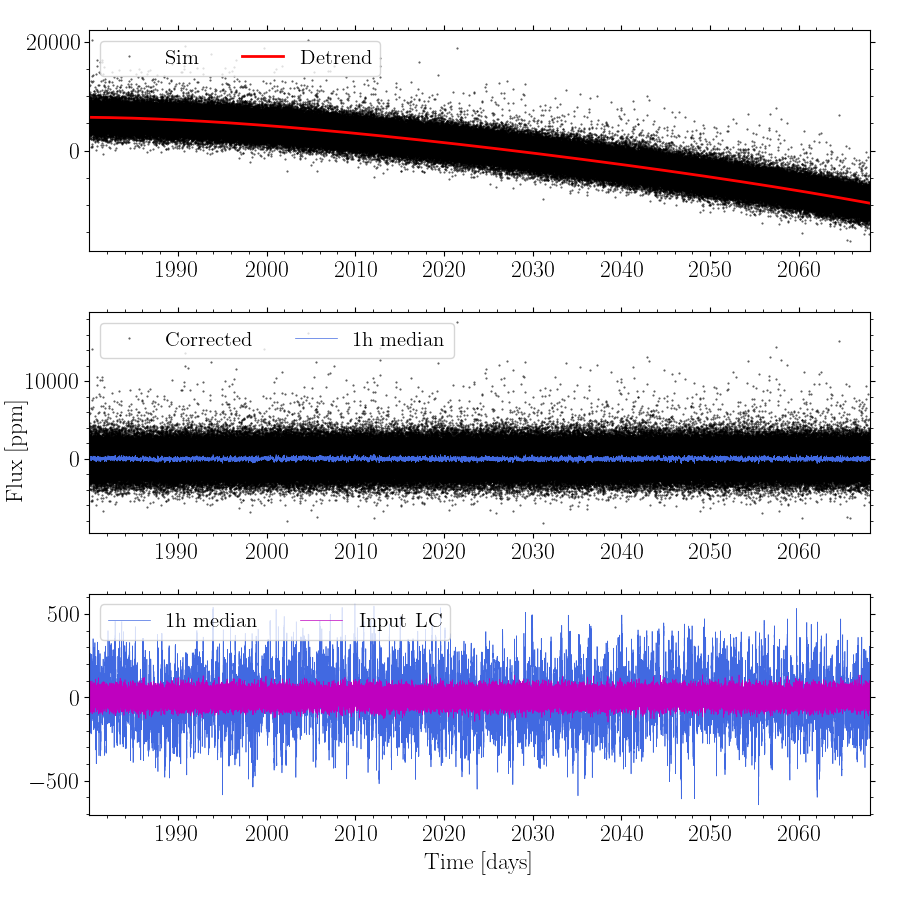

In [13]:
# Detrend light curve
lc.plot_detrend(poly_deg=4, binsize=1);

In [ ]:
# Get NSR per 1h for detrended light curve 
lc.detrend(poly_deg=3)
lc.getNSR(column="flux_det", binhour=1, influx="ppm")

In [ ]:
# With the long trend systematics the NSR is somewhat larger
lc.getNSR()

In [ ]:
# Remove files again to keep server clean
phot.remove()